# Analysing and plotting Tynitag Thermistor Data

This notebook provides a workflow for analysing and plotting thermistor data from glacier boreholes. It uses custom modules for data processing and visualization.

## 1. Import Required Libraries and Modules

Import pandas, matplotlib, and custom modules. Set the working directory and import calibration references.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Set working directory
os.chdir('/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes/')

# Import custom modules
from processing.thermistor_processing import *
from processing.thermistor_plotting import *   # NEW: plotting moved here
from processing.plot_composer import *          # for compose_plots
from processing.gpr_plotting import *          # for format_plot

## 2. Set Data and Output Paths

Define paths for calibration data, temperature data, and output figures.

In [2]:
# Calibration and temperature data paths
cal_path  = '/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/data/fieldwork_data/THERMAP_2024_2025/icetemperature_data/NTC_tynitag/calibration_data/'
temp_path = '/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/data/fieldwork_data/THERMAP_2024_2025/icetemperature_data/NTC_tynitag/temperature_data/full_timeseries/'

# Output path for figures
output_path = '/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes/products/figures/'

## 3. Plot Raw Temperature Data for Each Glacier

Set file paths for glacier borehole data, create ThermistorDataPlotter objects, and plot temperature profiles for each glacier.

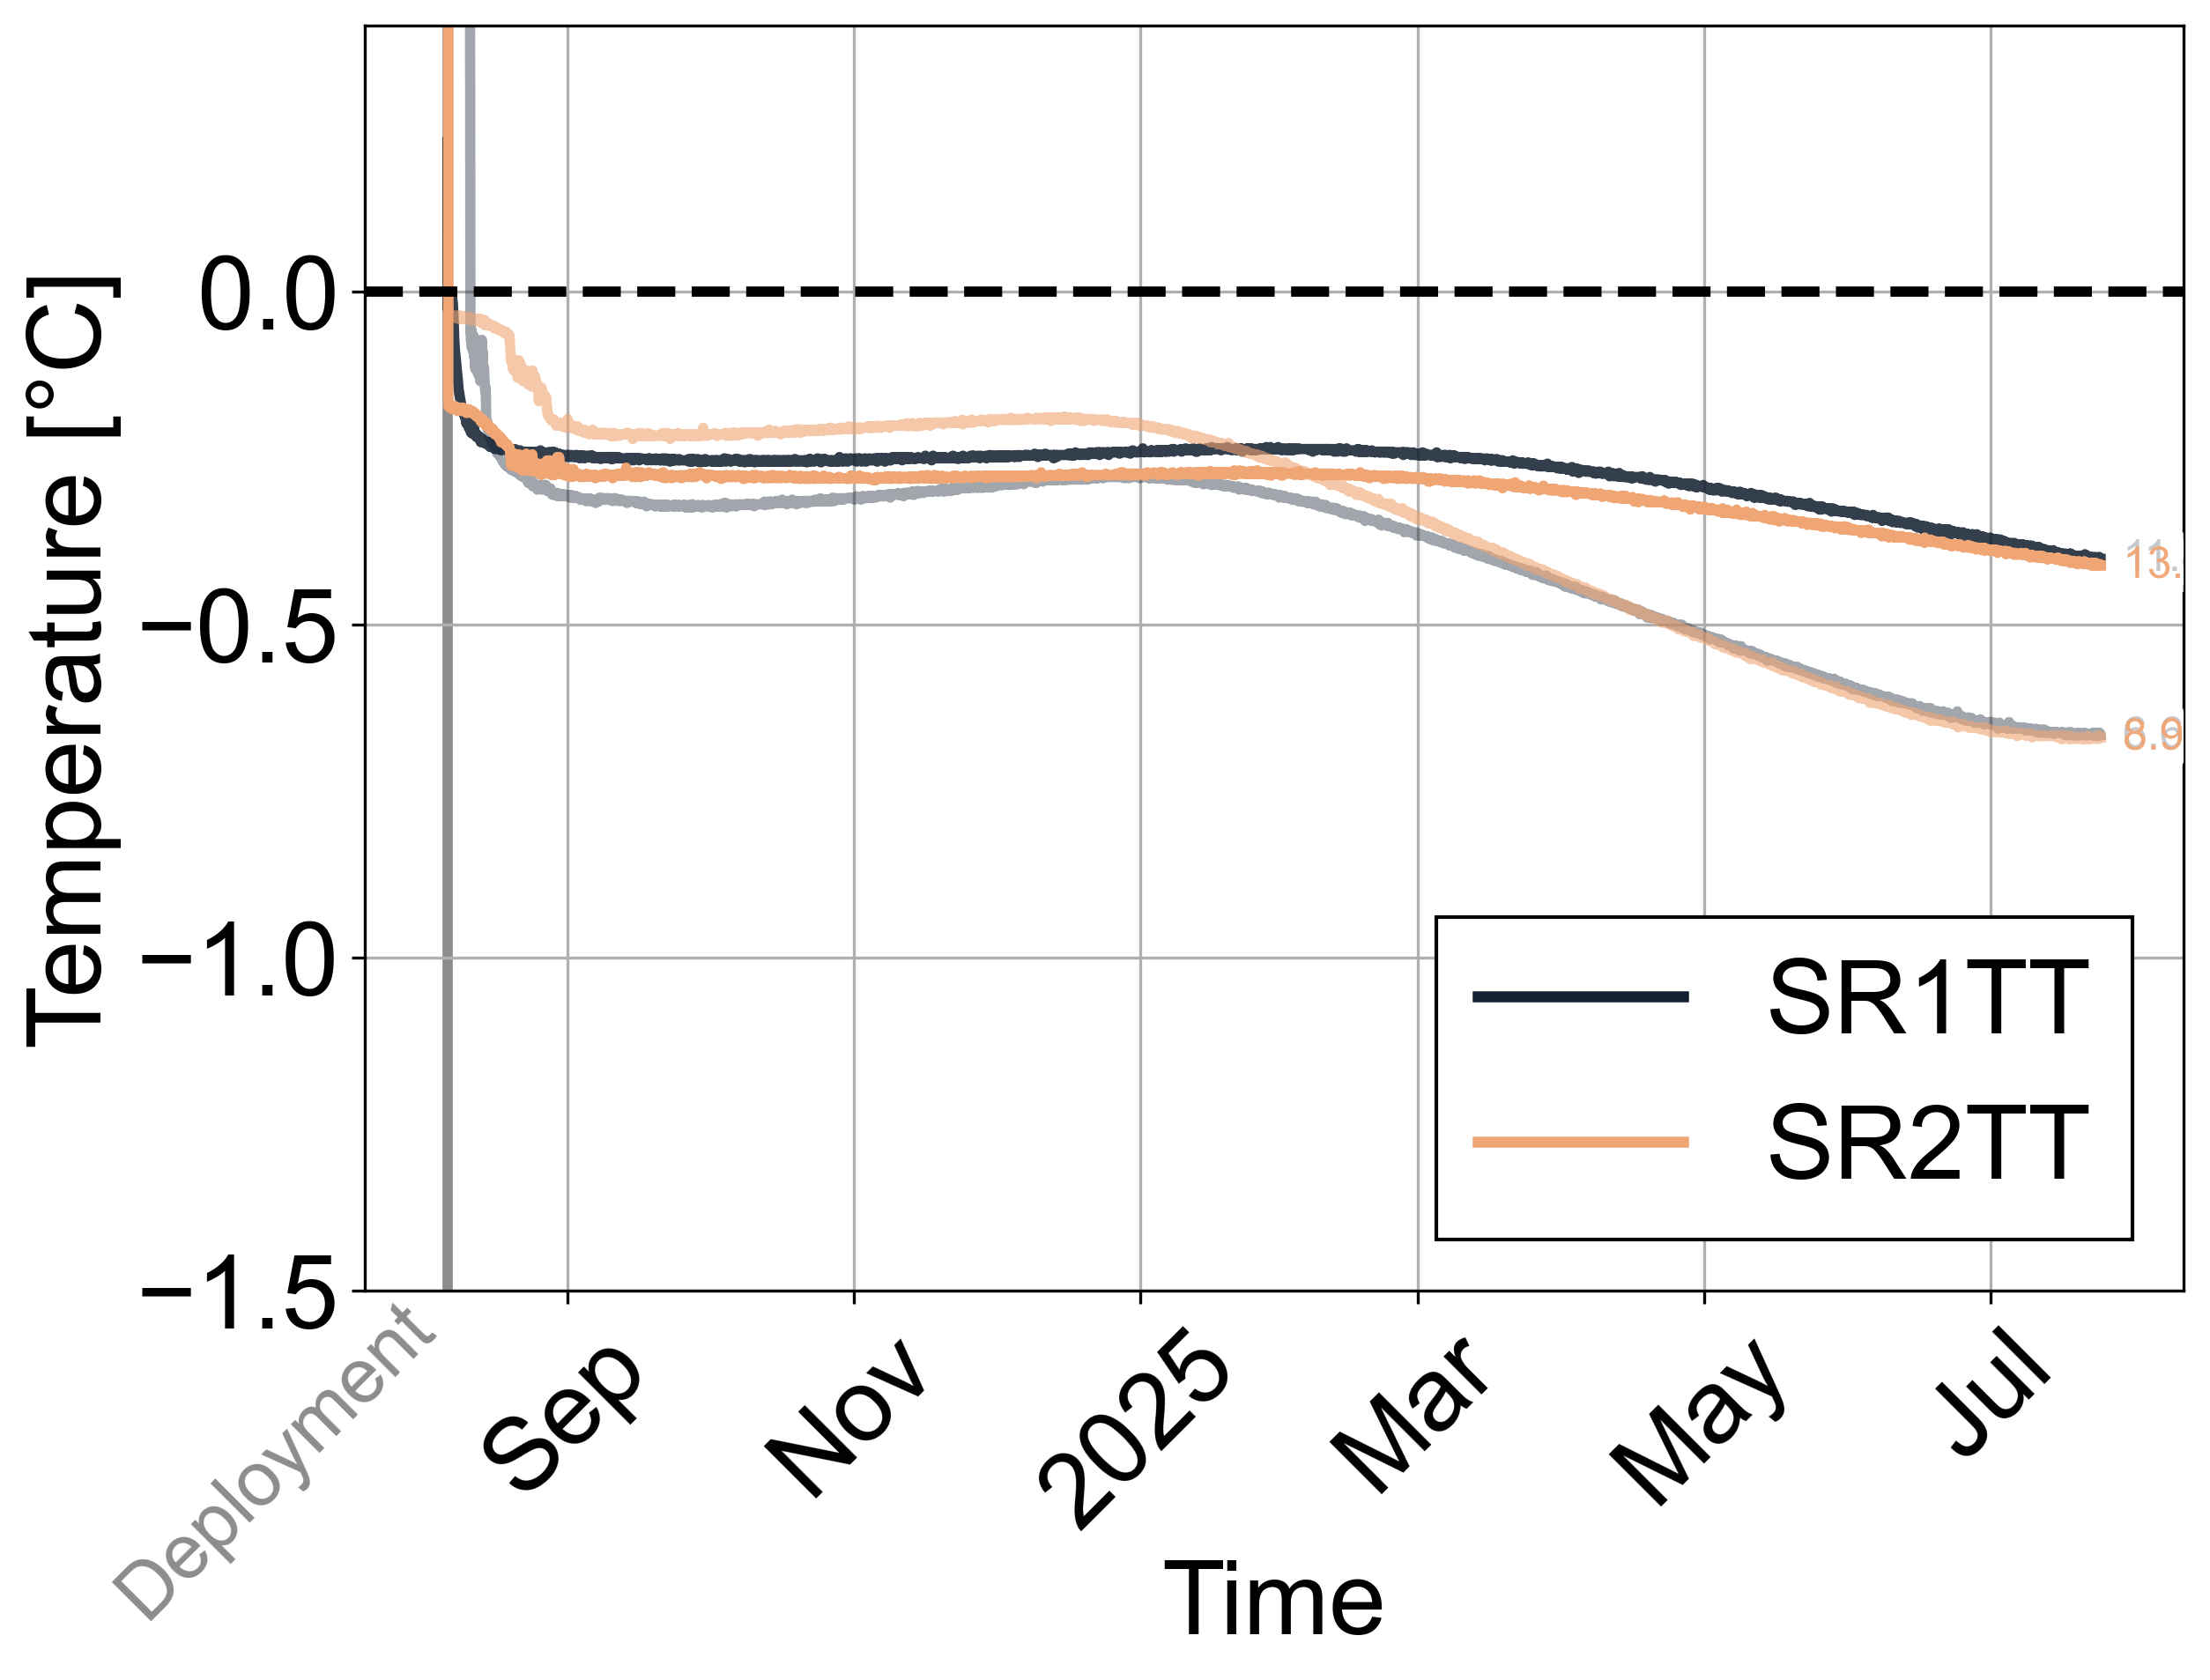

In [3]:
# Glacier borehole data file paths
sex_rouge_dirs = [temp_path + 'SR1TT_20240806_20250724_spliced.csv', temp_path + 'SR2TT_20240806_20250724_spliced.csv']
tortin_dirs    = [temp_path + 'GT1TT_20240807_20250723_spliced.csv', temp_path + 'GT2TT_20240807_20250723_spliced.csv']
hohsaas_dirs   = [temp_path + 'HS1TT_20240808_20250927_spliced.csv', temp_path + 'HS2TT_20240808_20250927_spliced.csv']
chessjen_dirs  = [temp_path + 'CJ1TT_20240809_20250808_spliced.csv', temp_path + 'CJ2TT_20240809_20250808_spliced.csv']
alphubel_dirs  = [temp_path + 'AH1TT_20250322_20250916.csv', temp_path + 'AH2TT_20240821_20250916_spliced.csv']  # no data for BH9
corvatsch_dirs = [temp_path + 'CT1TT_20240828_20250905.csv', temp_path + 'CT2TT_20240828_20250905_spliced.csv'] # no data for BH11

# Create plotter objects for each glacier
sex_rouge = ThermistorDataPlotter(sex_rouge_dirs, delimiter=',')
tortin    = ThermistorDataPlotter(tortin_dirs, delimiter=',')
hohsaas   = ThermistorDataPlotter(hohsaas_dirs, delimiter=',')
chessjen  = ThermistorDataPlotter(chessjen_dirs, delimiter=',')
alphubel  = ThermistorDataPlotter(alphubel_dirs, delimiter=',')
corvatsch = ThermistorDataPlotter(corvatsch_dirs, delimiter=',')

# Generate per-glacier TT figures (example depths; adjust your initial/current per glacier)
sr_init = [10.0,15.25,10.0,14.45]; sr_curr = [6.57,11.82,8.93,13.38]
gt_init = [4.2,9.2,8.3,13.3];     gt_curr = [1.43,6.43,4.87,9.87]
hs_init = [10.6,15.6,10.4,15.4];  hs_curr = [8.3,13.3,7.5,12.5]
cj_init = [6.8,11.8,8.5,13.5];    cj_curr = [4.1,9.1,5.48,10.48]
ah_init = [10.0,15.0,9.0,14.0];    ah_curr = [9.57,14.57,7.81,12.81]
cv_init = [2.0,7.0,4.3,9.3];      cv_curr = [1.26,6.26,3.09,8.09]

fig_sr, _ = sex_rouge.plot_multiple_ntc_boreholes(
    savepath=output_path + 'icetemp_results/',
    depths=sr_curr,
    borehole_labels=['SR1TT','SR2TT'],
    lower_y_limit=-1.5,
    initial_depths=sr_init
)

## 4. Generate mosaic plot for publication that shows temperature records of 3 glaciers in a row

/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes/processing/thermistor_plotting.py:443: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  d = d.resample("6H").mean().interpolate("time", limit_direction="both")
/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes/processing/thermistor_plotting.py:443: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  d = d.resample("6H").mean().interpolate("time", limit_direction="both")
/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes/processing/thermistor_plotting.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss

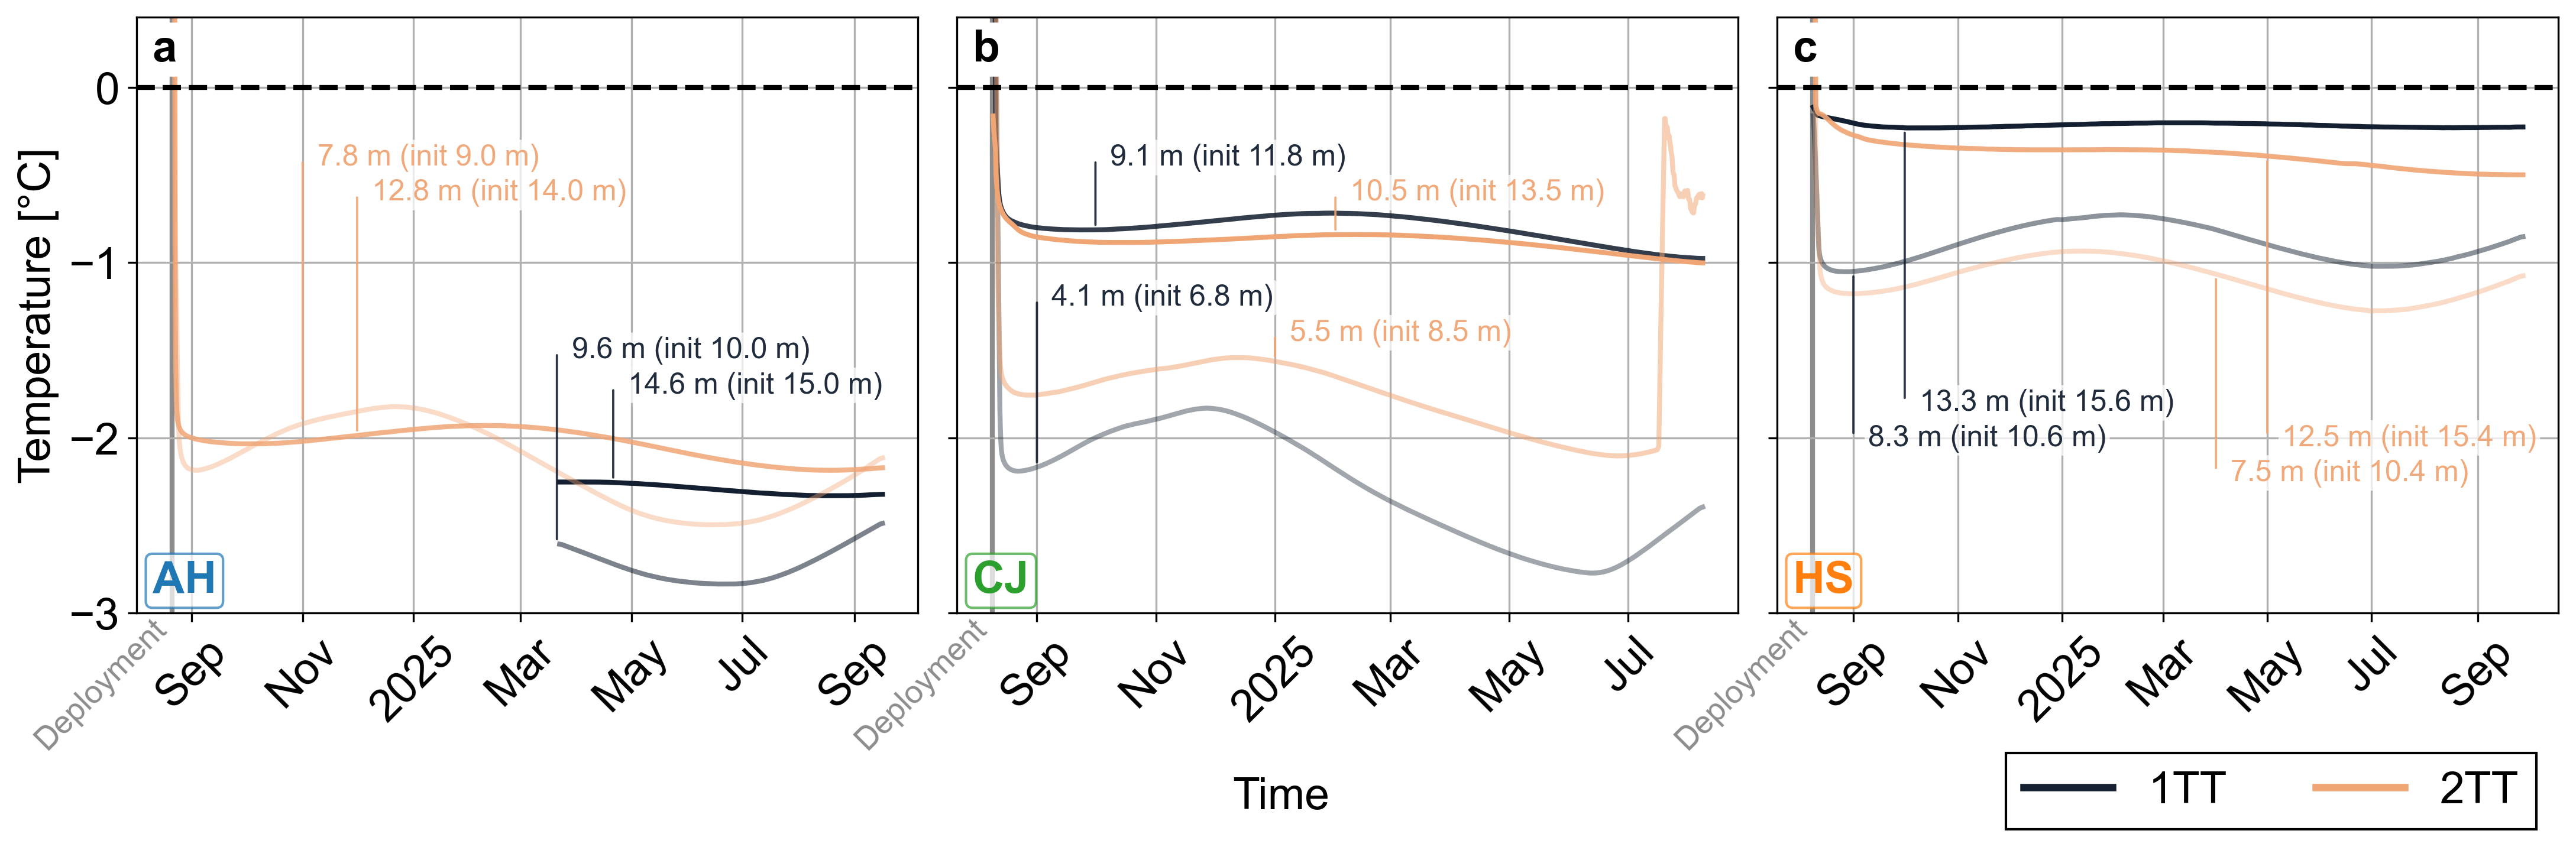

In [4]:
plotters = {"SR": sex_rouge, "GT": tortin, "HS": hohsaas, "CJ": chessjen, "AH": alphubel, "CV": corvatsch}
depths_current = {"SR": sr_curr, "GT": gt_curr, "HS": hs_curr, "CJ": cj_curr, "AH": ah_curr, "CV": cv_curr}
depths_initial = {"SR": sr_init, "GT": gt_init, "HS": hs_init, "CJ": cj_init, "AH": ah_init, "CV": cv_init}
labels = {"SR": ["SR1TT","SR2TT"], "GT": ["GT1TT","GT2TT"], "HS": ["HS1TT","HS2TT"],
          "CJ": ["CJ1TT","CJ2TT"], "AH": ["AH1TT","AH2TT"], "CV": ["CV1TT","CV2TT"]}
ylims = {"SR": -1.5, "GT": -4.0, "HS": -1.5, "CJ": -2.5, "AH": -3.5, "CV": -5.5}

# In analyze_tynitag.ipynb (call section)
ann_pos = {
    "AH": [("2025-03-21", -1.5), ("2025-04-21", -1.7), ("2024-11-01", -0.40), ("2024-12-01", -0.60)],  # None x = line end, custom y
    "CJ": [("2024-09-01", -1.2), ("2024-10-01", -0.4), ("2025-01-01", -1.4), ("2025-02-01", -0.6)],
    "HS": [("2024-09-01", -2.0), ("2024-10-01", -1.8), ("2025-04-01", -2.2), ("2025-05-01", -2.0)]
}

fig_row1 = build_tyntag_timeseries_one_row(
    order=("AH", "CJ", "HS"),
    plotters=plotters,
    depths_current=depths_current,
    depths_initial=depths_initial,
    labels=labels,
    lower_y_limit=-3.0,
    figsize=(15, 4.8),
    dpi=300,
    base_fontsize=18,
    legend_fontsize=18,
    legend_position="lower_right",
    legend_anchor=(0.98, -0.02),
    smooth_days=3,
    annotation_positions=ann_pos,
    annotation_fontsize=12,    # NEW
    xlabel_y=0.02,             # lower the shared x-axis label
    wspace=0.05,               # increase horizontal space between subplots
    savefig_path=output_path + "icetemp_results/tynitag/tt_timeseries_AH_CJ_HS.png",
)

/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes/processing/thermistor_plotting.py:443: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  d = d.resample("6H").mean().interpolate("time", limit_direction="both")
/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes/processing/thermistor_plotting.py:443: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  d = d.resample("6H").mean().interpolate("time", limit_direction="both")
/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes/processing/thermistor_plotting.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss

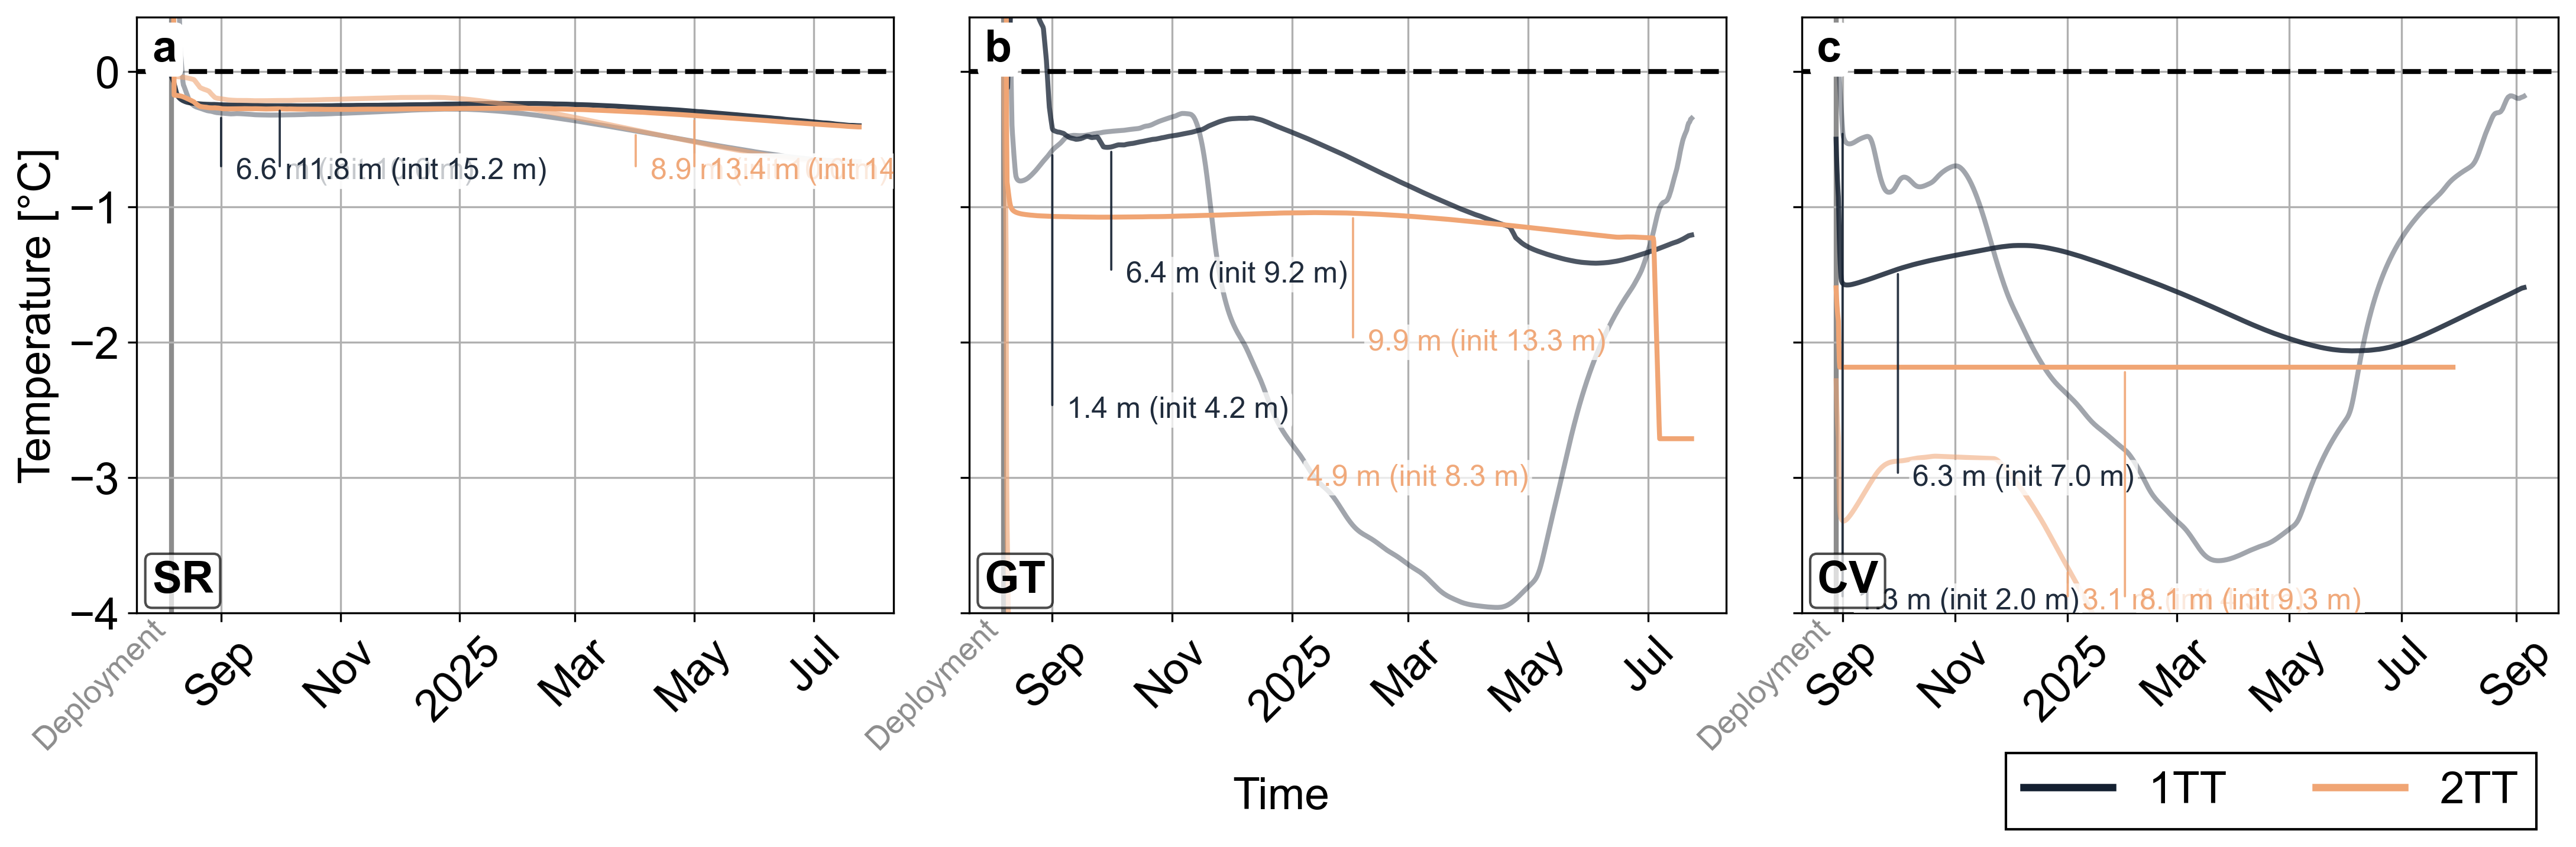

In [5]:
ann_pos_2 = {
    "SR": [("2024-09-01", -1.0), ("2024-10-01", -2.0), ("2025-04-01", -1.0), ("2025-05-01", -2.0)],
    "GT": [("2024-09-01", -2.5), ("2024-10-01", -1.5), ("2025-01-01", -3.0), ("2025-02-01", -2.0)],
    "CV": [("2024-09-01", -4.0), ("2024-10-01", -3.0), ("2025-01-01", -5.0), ("2025-02-01", -4.0)]
}

fig_row2 = build_tyntag_timeseries_one_row(
    order=("SR", "GT", "CV"),
    plotters=plotters,
    depths_current=depths_current,
    depths_initial=depths_initial,
    labels=labels,
    lower_y_limit=-4.0,
    figsize=(15, 4.8),
    dpi=300,
    panel_labels= {"SR": "a", "GT": "b", "CV": "c"},
    base_fontsize=18,
    legend_fontsize=18,
    legend_position="lower_right",
    legend_anchor=(0.98, -0.02),
    smooth_days=3,
    annotation_positions=ann_pos_2,
    annotation_fontsize=12,    # NEW
    xlabel_y=0.02,             # lower the shared x-axis label
    wspace=0.1,               # increase horizontal space between subplots
    savefig_path=output_path + "icetemp_results/tynitag/tt_timeseries_SR_GT_CV.png",
)